In [2]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

In [12]:
OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
SENTS = OHCO[:4]

# Subset of columns from salex
emo_cols = "anger anticipation disgust fear joy sadness surprise trust sentiment".split()

TOKENS = pd.read_csv("Data\CORPUS\FULL_CORPUS.csv").set_index(OHCO).sort_index()
SALEX = pd.read_csv('Data/salex_nrc.csv').set_index('term_str')
SALEX.columns = [col.replace('nrc_','') for col in SALEX.columns]

LIB = pd.read_csv('Data\LIB.csv').set_index('book_id').sort_index()


<>:7: SyntaxWarning: invalid escape sequence '\C'
<>:11: SyntaxWarning: invalid escape sequence '\L'
<>:7: SyntaxWarning: invalid escape sequence '\C'
<>:11: SyntaxWarning: invalid escape sequence '\L'
C:\Users\school\AppData\Local\Temp\ipykernel_39884\2635196891.py:7: SyntaxWarning: invalid escape sequence '\C'
  TOKENS = pd.read_csv("Data\CORPUS\FULL_CORPUS.csv").set_index(OHCO).sort_index()
C:\Users\school\AppData\Local\Temp\ipykernel_39884\2635196891.py:11: SyntaxWarning: invalid escape sequence '\L'
  LIB = pd.read_csv('Data\LIB.csv').set_index('book_id').sort_index()
C:\Users\school\AppData\Local\Temp\ipykernel_39884\2635196891.py:7: DtypeWarning: Columns (5,6,9) have mixed types. Specify dtype option on import or set low_memory=False.
  TOKENS = pd.read_csv("Data\CORPUS\FULL_CORPUS.csv").set_index(OHCO).sort_index()


In [13]:
TOKENS = TOKENS.join(LIB)
TOKENS.head()


pos_tuple  pos token_str  \
book_id chap_num para_num sent_num token_num                            
43      1        0        0        0               NaN  NaN       Mr.   
                                   1               NaN  NaN  Utterson   
                                   2               NaN  NaN       the   
                                   3               NaN  NaN    lawyer   
                                   4               NaN  NaN       was   

                                              term_str pos_group short_name  \
book_id chap_num para_num sent_num token_num                                  
43      1        0        0        0                mr       NaN     jekyll   
                                   1          utterson       NaN     jekyll   
                                   2               the       NaN     jekyll   
                                   3            lawyer       NaN     jekyll   
                                   4               was       NaN     jekyll   

                                                    era  date novel_type  
book_id chap_num para_num sent_num token_num                              
43      1        0        0        0          victorian  1886   thriller  
                                   1          victorian  1886   thriller  
                                   2          victorian  1886   thriller  
                                   3          victorian  1886   thriller  
                                   4          victorian  1886   thriller

In [14]:
TOKENS_SA = TOKENS.join(SALEX, on='term_str', how='left').fillna(0)
TOKENS_SA

pos_tuple  pos token_str  \
book_id  chap_num para_num sent_num token_num                            
43       1        0        0        0                 0    0       Mr.   
                                    1                 0    0  Utterson   
                                    2                 0    0       the   
                                    3                 0    0    lawyer   
                                    4                 0    0       was   
...                                                 ...  ...       ...   
20180856 9        119      4        34                0  WDT  whatever   
                                    35                0  VBD    walked   
                                    36                0   RB     there   
                                    38                0  VBD    walked   
                                    39                0   RB     alone   

                                               term_str pos_group  \
book_id  chap_num para_num sent_num token_num                       
43       1        0        0        0                mr         0   
                                    1          utterson         0   
                                    2               the         0   
                                    3            lawyer         0   
                                    4               was         0   
...                                                 ...       ...   
20180856 9        119      4        34         whatever        WD   
                                    35           walked        VB   
                                    36            there        RB   
                                    38           walked        VB   
                                    39            alone        RB   

                                                           short_name  \
book_id  chap_num para_num sent_num token_num                           
43       1        0        0        0                          jekyll   
                                    1                          jekyll   
                                    2                          jekyll   
                                    3                          jekyll   
                                    4                          jekyll   
...                                                               ...   
20180856 9        119      4        34         haunting_of_hill_house   
                                    35         haunting_of_hill_house   
                                    36         haunting_of_hill_house   
                                    38         haunting_of_hill_house   
                                    39         haunting_of_hill_house   

                                                     era  date novel_type  \
book_id  chap_num para_num sent_num token_num                               
43       1        0        0        0          victorian  1886   thriller   
                                    1          victorian  1886   thriller   
                                    2          victorian  1886   thriller   
                                    3          victorian  1886   thriller   
                                    4          victorian  1886   thriller   
...                                                  ...   ...        ...   
20180856 9        119      4        34            modern  1959   thriller   
                                    35            modern  1959   thriller   
                                    36            modern  1959   thriller   
                                    38            modern  1959   thriller   
                                    39            modern  1959   thriller   

                                               anger  anticipation  disgust  \
book_id  chap_num para_num sent_num token_num                                 
43       1        0        0        0            0.0           0.0      0.0

In [15]:
TOKENS_SA = TOKENS.join(SALEX, on='term_str', how='left').fillna(0)
TOKENS_SA

pos_tuple  pos token_str  \
book_id  chap_num para_num sent_num token_num                            
43       1        0        0        0                 0    0       Mr.   
                                    1                 0    0  Utterson   
                                    2                 0    0       the   
                                    3                 0    0    lawyer   
                                    4                 0    0       was   
...                                                 ...  ...       ...   
20180856 9        119      4        34                0  WDT  whatever   
                                    35                0  VBD    walked   
                                    36                0   RB     there   
                                    38                0  VBD    walked   
                                    39                0   RB     alone   

                                               term_str pos_group  \
book_id  chap_num para_num sent_num token_num                       
43       1        0        0        0                mr         0   
                                    1          utterson         0   
                                    2               the         0   
                                    3            lawyer         0   
                                    4               was         0   
...                                                 ...       ...   
20180856 9        119      4        34         whatever        WD   
                                    35           walked        VB   
                                    36            there        RB   
                                    38           walked        VB   
                                    39            alone        RB   

                                                           short_name  \
book_id  chap_num para_num sent_num token_num                           
43       1        0        0        0                          jekyll   
                                    1                          jekyll   
                                    2                          jekyll   
                                    3                          jekyll   
                                    4                          jekyll   
...                                                               ...   
20180856 9        119      4        34         haunting_of_hill_house   
                                    35         haunting_of_hill_house   
                                    36         haunting_of_hill_house   
                                    38         haunting_of_hill_house   
                                    39         haunting_of_hill_house   

                                                     era  date novel_type  \
book_id  chap_num para_num sent_num token_num                               
43       1        0        0        0          victorian  1886   thriller   
                                    1          victorian  1886   thriller   
                                    2          victorian  1886   thriller   
                                    3          victorian  1886   thriller   
                                    4          victorian  1886   thriller   
...                                                  ...   ...        ...   
20180856 9        119      4        34            modern  1959   thriller   
                                    35            modern  1959   thriller   
                                    36            modern  1959   thriller   
                                    38            modern  1959   thriller   
                                    39            modern  1959   thriller   

                                               anger  anticipation  disgust  \
book_id  chap_num para_num sent_num token_num                                 
43       1        0        0        0            0.0           0.0      0.0

# Make SENT_VOCAB

In [44]:
TOKENS_SA['overall_sent'] = TOKENS_SA[emo_cols].sum(1)

In [56]:
VOCAB = TOKENS_SA.term_str.value_counts().to_frame('n')
VOCAB.index.name = 'term_str'

In [57]:
import numpy as np

VOCAB = TOKENS_SA.term_str.value_counts().to_frame('n')
VOCAB.index.name = 'term_str'
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
VOCAB['i'] = -np.log2(VOCAB.p)
VOCAB['n_chars'] = VOCAB.index.str.len()
VOCAB

,n,p,i,n_chars
term_str,,,,
the,36126,0.053226,4.231718,3.0
0,34353,0.050614,4.304319,NaN
and,22280,0.032826,4.929006,3.0
to,18949,0.027919,5.162634,2.0
of,17802,0.026229,5.252716,2.0
...,...,...,...,...
hugging,1,0.000001,19.372468,7.0
weatherworn,1,0.000001,19.372468,11.0
peeked,1,0.000001,19.372468,6.0


In [58]:
VOCAB['max_pos_group'] = TOKENS_SA[['term_str','pos_group']].value_counts().unstack(fill_value=0).idxmax(1)
VOCAB['max_pos'] = TOKENS_SA[['term_str','pos']].value_counts().unstack(fill_value=0).idxmax(1)
VOCAB['overall_sent'] = TOKENS_SA[['term_str','overall_sent']].value_counts().unstack(fill_value=0).idxmax(1)

VOCAB

,n,p,i,n_chars,max_pos_group,max_pos,overall_sent
term_str,,,,,,,
the,36126,0.053226,4.231718,3.0,DT,DT,0.0
0,34353,0.050614,4.304319,NaN,",",",",0.0
and,22280,0.032826,4.929006,3.0,CC,CC,0.0
to,18949,0.027919,5.162634,2.0,TO,TO,0.0
of,17802,0.026229,5.252716,2.0,IN,IN,0.0
...,...,...,...,...,...,...,...
hugging,1,0.000001,19.372468,7.0,VB,VBG,0.0
weatherworn,1,0.000001,19.372468,11.0,0,0,0.0
peeked,1,0.000001,19.372468,6.0,VB,VBD,0.0


In [59]:
VOCAB.to_csv('Data/SENT_VOCAB.csv')

# SENt_BOW

In [76]:
OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
bags = dict(
    SENTS = OHCO[:4],
    PARAS = OHCO[:3],
    CHAPS = OHCO[:2],
    BOOKS = OHCO[:1]
)
bag = 'CHAPS'
BOW = TOKENS_SA.groupby(bags[bag]+['term_str']).term_str.count().to_frame('n') 
BOW.head()

n
book_id chap_num term_str    
43      1        0         17
                 a         79
                 able       1
                 about      9
                 abreast    1

In [77]:
BOW['overall_sent'] = TOKENS_SA.groupby(bags[bag] + ['term_str'])['overall_sent'].sum()


In [78]:
BOW.head(50)

n  overall_sent
book_id chap_num term_str                      
43      1        0             17           0.0
                 a             79           0.0
                 able           1           0.0
                 about          9           0.0
                 abreast        1           0.0
                 accent         1           0.0
                 accept         1           0.0
                 accident       1           2.0
                 according      1           0.0
                 acquaintance   1           0.0
                 acts           1           0.0
                 added          2           0.0
                 address        1           0.0
                 adventure      1           2.0
                 affections     1           0.0
                 affirmative    1           0.0
                 after          3           0.0
                 again          3           0.0
                 age            1           0.0
                 ago            1           0.0
                 air            1           0.0
                 all           12           0.0
                 almost         1           0.0
                 alone          1           0.0
                 along          2           0.0
                 already        2           0.0
                 although       1           0.0
                 always         1           0.0
                 am             2           0.0
                 an             5           0.0
                 and           87           0.0
                 another        4           0.0
                 any            4           0.0
                 apocryphal     1           0.0
                 apothecary     1           0.0
                 appearance     3           0.0
                 appeared       1           0.0
                 approved       1           0.0
                 aptness        1           0.0
                 are            4           0.0
                 as            17           0.0
                 ashamed        1           1.0
                 aside          1           0.0
                 ask            4           0.0
                 asked          2           0.0
                 asking         1           0.0
                 asleepstreet   1           0.0
                 at            16           0.0
                 austere        1           1.0
                 avoid          1           0.0

In [79]:
BOW = BOW.drop(columns='n')

In [80]:
BOW.head(50)

overall_sent
book_id chap_num term_str                  
43      1        0                      0.0
                 a                      0.0
                 able                   0.0
                 about                  0.0
                 abreast                0.0
                 accent                 0.0
                 accept                 0.0
                 accident               2.0
                 according              0.0
                 acquaintance           0.0
                 acts                   0.0
                 added                  0.0
                 address                0.0
                 adventure              2.0
                 affections             0.0
                 affirmative            0.0
                 after                  0.0
                 again                  0.0
                 age                    0.0
                 ago                    0.0
                 air                    0.0
                 all                    0.0
                 almost                 0.0
                 alone                  0.0
                 along                  0.0
                 already                0.0
                 although               0.0
                 always                 0.0
                 am                     0.0
                 an                     0.0
                 and                    0.0
                 another                0.0
                 any                    0.0
                 apocryphal             0.0
                 apothecary             0.0
                 appearance             0.0
                 appeared               0.0
                 approved               0.0
                 aptness                0.0
                 are                    0.0
                 as                     0.0
                 ashamed                1.0
                 aside                  0.0
                 ask                    0.0
                 asked                  0.0
                 asking                 0.0
                 asleepstreet           0.0
                 at                     0.0
                 austere                1.0
                 avoid                  0.0

In [81]:
BOW.to_csv('Data/SENT_BOW.csv')

# DOC_SENT

In [83]:
DTCM = BOW.overall_sent.unstack(fill_value=0)
DTCM.head(10)

term_str            0  000    1   10  100  1018  1030  10th   11  1140  ...  \
book_id chap_num                                                        ...   
43      1         0.0  0.0  0.0  0.0  0.0   0.0   0.0   0.0  0.0   0.0  ...   
        2         0.0  0.0  0.0  0.0  0.0   0.0   0.0   0.0  0.0   0.0  ...   
        3         0.0  0.0  0.0  0.0  0.0   0.0   0.0   0.0  0.0   0.0  ...   
        4         0.0  0.0  0.0  0.0  0.0   0.0   0.0   0.0  0.0   0.0  ...   
        5         0.0  0.0  0.0  0.0  0.0   0.0   0.0   0.0  0.0   0.0  ...   
        6         0.0  0.0  0.0  0.0  0.0   0.0   0.0   0.0  0.0   0.0  ...   
        7         0.0  0.0  0.0  0.0  0.0   0.0   0.0   0.0  0.0   0.0  ...   
        8         0.0  0.0  0.0  0.0  0.0   0.0   0.0   0.0  0.0   0.0  ...   
        9         0.0  0.0  0.0  0.0  0.0   0.0   0.0   0.0  0.0   0.0  ...   
175     1         0.0  0.0  0.0  0.0  0.0   0.0   0.0   0.0  0.0   0.0  ...   

term_str          zoöphagy  zurich    à  æneis  æra   æt  ætat  æther  état  \
book_id chap_num                                                              
43      1              0.0     0.0  0.0    0.0  0.0  0.0   0.0    0.0   0.0   
        2              0.0     0.0  0.0    0.0  0.0  0.0   0.0    0.0   0.0   
        3              0.0     0.0  0.0    0.0  0.0  0.0   0.0    0.0   0.0   
        4              0.0     0.0  0.0    0.0  0.0  0.0   0.0    0.0   0.0   
        5              0.0     0.0  0.0    0.0  0.0  0.0   0.0    0.0   0.0   
        6              0.0     0.0  0.0    0.0  0.0  0.0   0.0    0.0   0.0   
        7              0.0     0.0  0.0    0.0  0.0  0.0   0.0    0.0   0.0   
        8              0.0     0.0  0.0    0.0  0.0  0.0   0.0    0.0   0.0   
        9              0.0     0.0  0.0    0.0  0.0  0.0   0.0    0.0   0.0   
175     1              0.0     0.0  0.0    0.0  0.0  0.0   0.0    0.0   0.0   

term_str          œdipus  
book_id chap_num          
43      1            0.0  
        2            0.0  
        3            0.0  
        4            0.0  
        5            0.0  
        6            0.0  
        7            0.0  
        8            0.0  
        9            0.0  
175     1            0.0  

[10 rows x 21505 columns]

In [85]:
DTCM.to_csv('Data/SENT_DOC.csv')

# Sent plot

In [16]:
BOOK_SA = TOKENS_SA.fillna(0).groupby('book_id')[emo_cols].mean()


In [17]:
def tag_term_str(x):
    if pd.isna(x.sentiment):
        html_str = x.term_str
    else:
        html_str = f"<span class='sent{int(np.sign(x.sentiment))}'>{x.term_str}</span>"
    return html_str

In [18]:
TOKENS_SA['html'] = TOKENS_SA.apply(tag_term_str, axis=1)

In [19]:
TOKENS_SA.sample(10).html

book_id  chap_num  para_num  sent_num  token_num
41445    14        7         1         7                 <span class='sent0'>read</span>
175      13        133       3         17             <span class='sent0'>curtain</span>
         9         12        3         11                  <span class='sent0'>or</span>
345      7         38        4         5             <span class='sent-1'>straits</span>
41445    13        20        2         3            <span class='sent0'>mentioned</span>
53685    4         3         19        33                <span class='sent0'>with</span>
345      15        18        9         20                 <span class='sent0'>the</span>
5182     1         869       0         7                    <span class='sent0'>0</span>
345      21        38        1         3                   <span class='sent0'>be</span>
         26        2         1         17               <span class='sent0'>hands</span>
Name: html, dtype: object

In [20]:
SENT_SA = TOKENS_SA.groupby(SENTS)[emo_cols].mean()
SENT_SA['html_str'] = TOKENS_SA.groupby(SENTS)[['html']].apply(lambda x: ' '.join(map(str, x.html)))

In [21]:
# This function will print sentences using color coding for sentiment values
def sample_sentences(df, n=10):
    
    rows = []
    for idx in df.sample(n).index:

        # Map background color to sentiment valences
        valence = round(df.loc[idx, 'sentiment'], 4)     
        if valence > 0: color = '#ccffcc'
        elif valence < 0: color = '#ffcccc'
        else: color = '#f2f2f2'

        # Create a table row
        rows.append(f"""
        <tr style="background-color:{color};padding:.5rem 1rem;font-size:110%;">
            <td>{idx}</td>
            <td width="400" style="text-align:left;">{df.loc[idx, 'html_str']}</td>
            <td>{valence}</td>
        </tr>
        """)

    # Define CSS style element to apply color to fonts by class
    display(HTML("""
    <style>
    #sample1 td{
        font-size:120%;
        vertical-align:top;
    } 
    .sent-1{
        color:red;
        font-weight:bold;
    } 
    .sent1{
        color:green;
        font-weight:bold;
    }
    </style>
    """))
    
    # Create the table
    display(HTML(f"""
    <table id="sample1">
        <tr>
            <th>ID</th>
            <th>Sentence</th>
            <th width="600">Valence</th>
        </tr>
        {"".join(rows)}
    </table>
    """))

In [22]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk import download as nltk_download
nltk_download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\school\AppData\Roaming\nltk_data...


True

In [23]:
analyser = SentimentIntensityAnalyzer()

In [24]:
SENT_SA['sent_str'] = TOKENS_SA.groupby(SENTS)[['term_str']].apply(lambda x: ' '.join(map(str, x.term_str)))
SENT_VADER = SENT_SA.sent_str.apply(analyser.polarity_scores).apply(pd.Series)
SENT_VADER.head()

neg    neu    pos  compound
book_id chap_num para_num sent_num                               
43      1        0        0         0.180  0.718  0.103   -0.2523
                          1         0.000  0.961  0.039    0.2732
                          2         0.057  0.850  0.093    0.3182
                          3         0.114  0.658  0.228    0.7199
                          4         0.087  0.855  0.058   -0.3612

In [30]:
def plot_book_sa(book_id, wf = 5):
    # wf: window size factor
    df = SENT_VADER.loc[book_id]
    w = int(df.shape[0] / wf)
    fig, axes = plt.subplots(3, 1, figsize=(25,15), sharex=True, sharey=False)
    plt.suptitle("Jekyll and Hyde", y=1, fontsize=20)
    df[['pos','neg']].rolling(w).mean().plot(ax=axes[0])
    df[['neu']].rolling(w).mean().plot(ax=axes[1])
    df[['compound']].rolling(w).mean().plot(ax=axes[2])
    plt.tight_layout()
    sns.despine(left=True)
    plt.show()

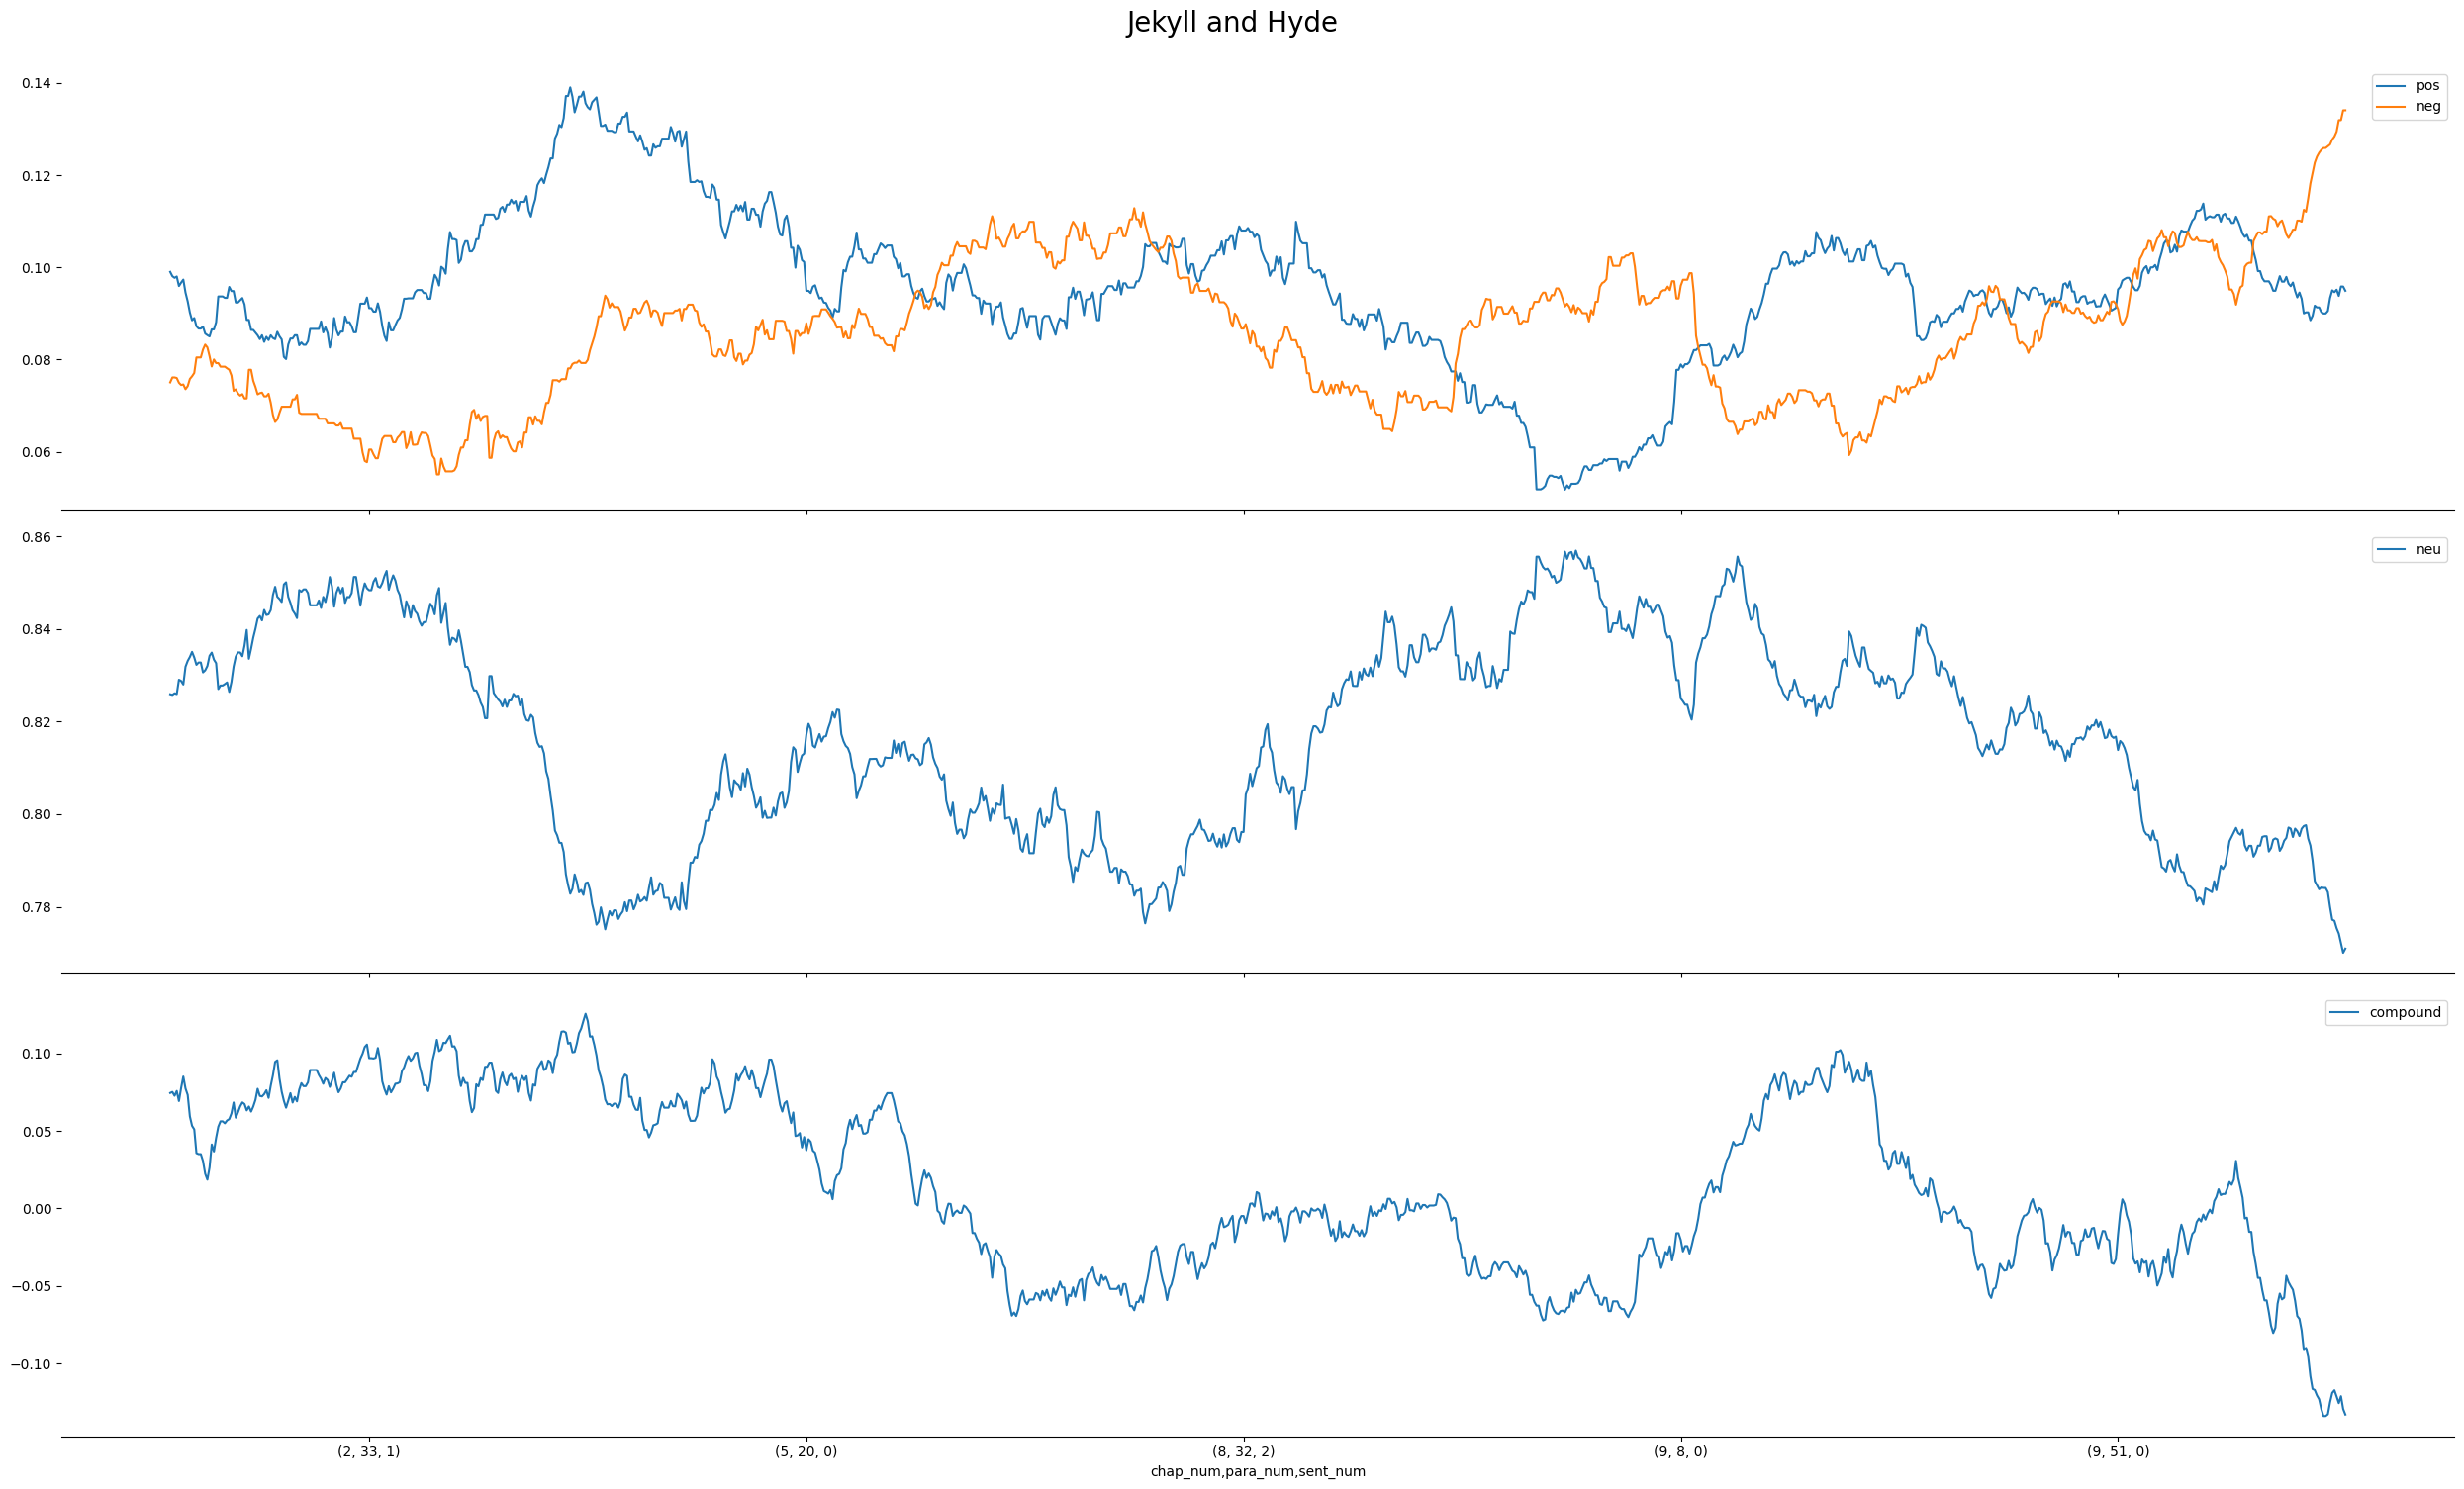

In [31]:
plot_book_sa(43, 10)

In [86]:
def plot_book_sa(book_id, wf = 5):
    # wf: window size factor
    df = SENT_VADER.loc[book_id]
    w = int(df.shape[0] / wf)
    fig, axes = plt.subplots(3, 1, figsize=(25,15), sharex=True, sharey=False)
    plt.suptitle("The Monkey's Paw", y=1, fontsize=20)
    df[['pos','neg']].rolling(w).mean().plot(ax=axes[0])
    df[['neu']].rolling(w).mean().plot(ax=axes[1])
    df[['compound']].rolling(w).mean().plot(ax=axes[2])
    plt.tight_layout()
    sns.despine(left=True)
    plt.show()

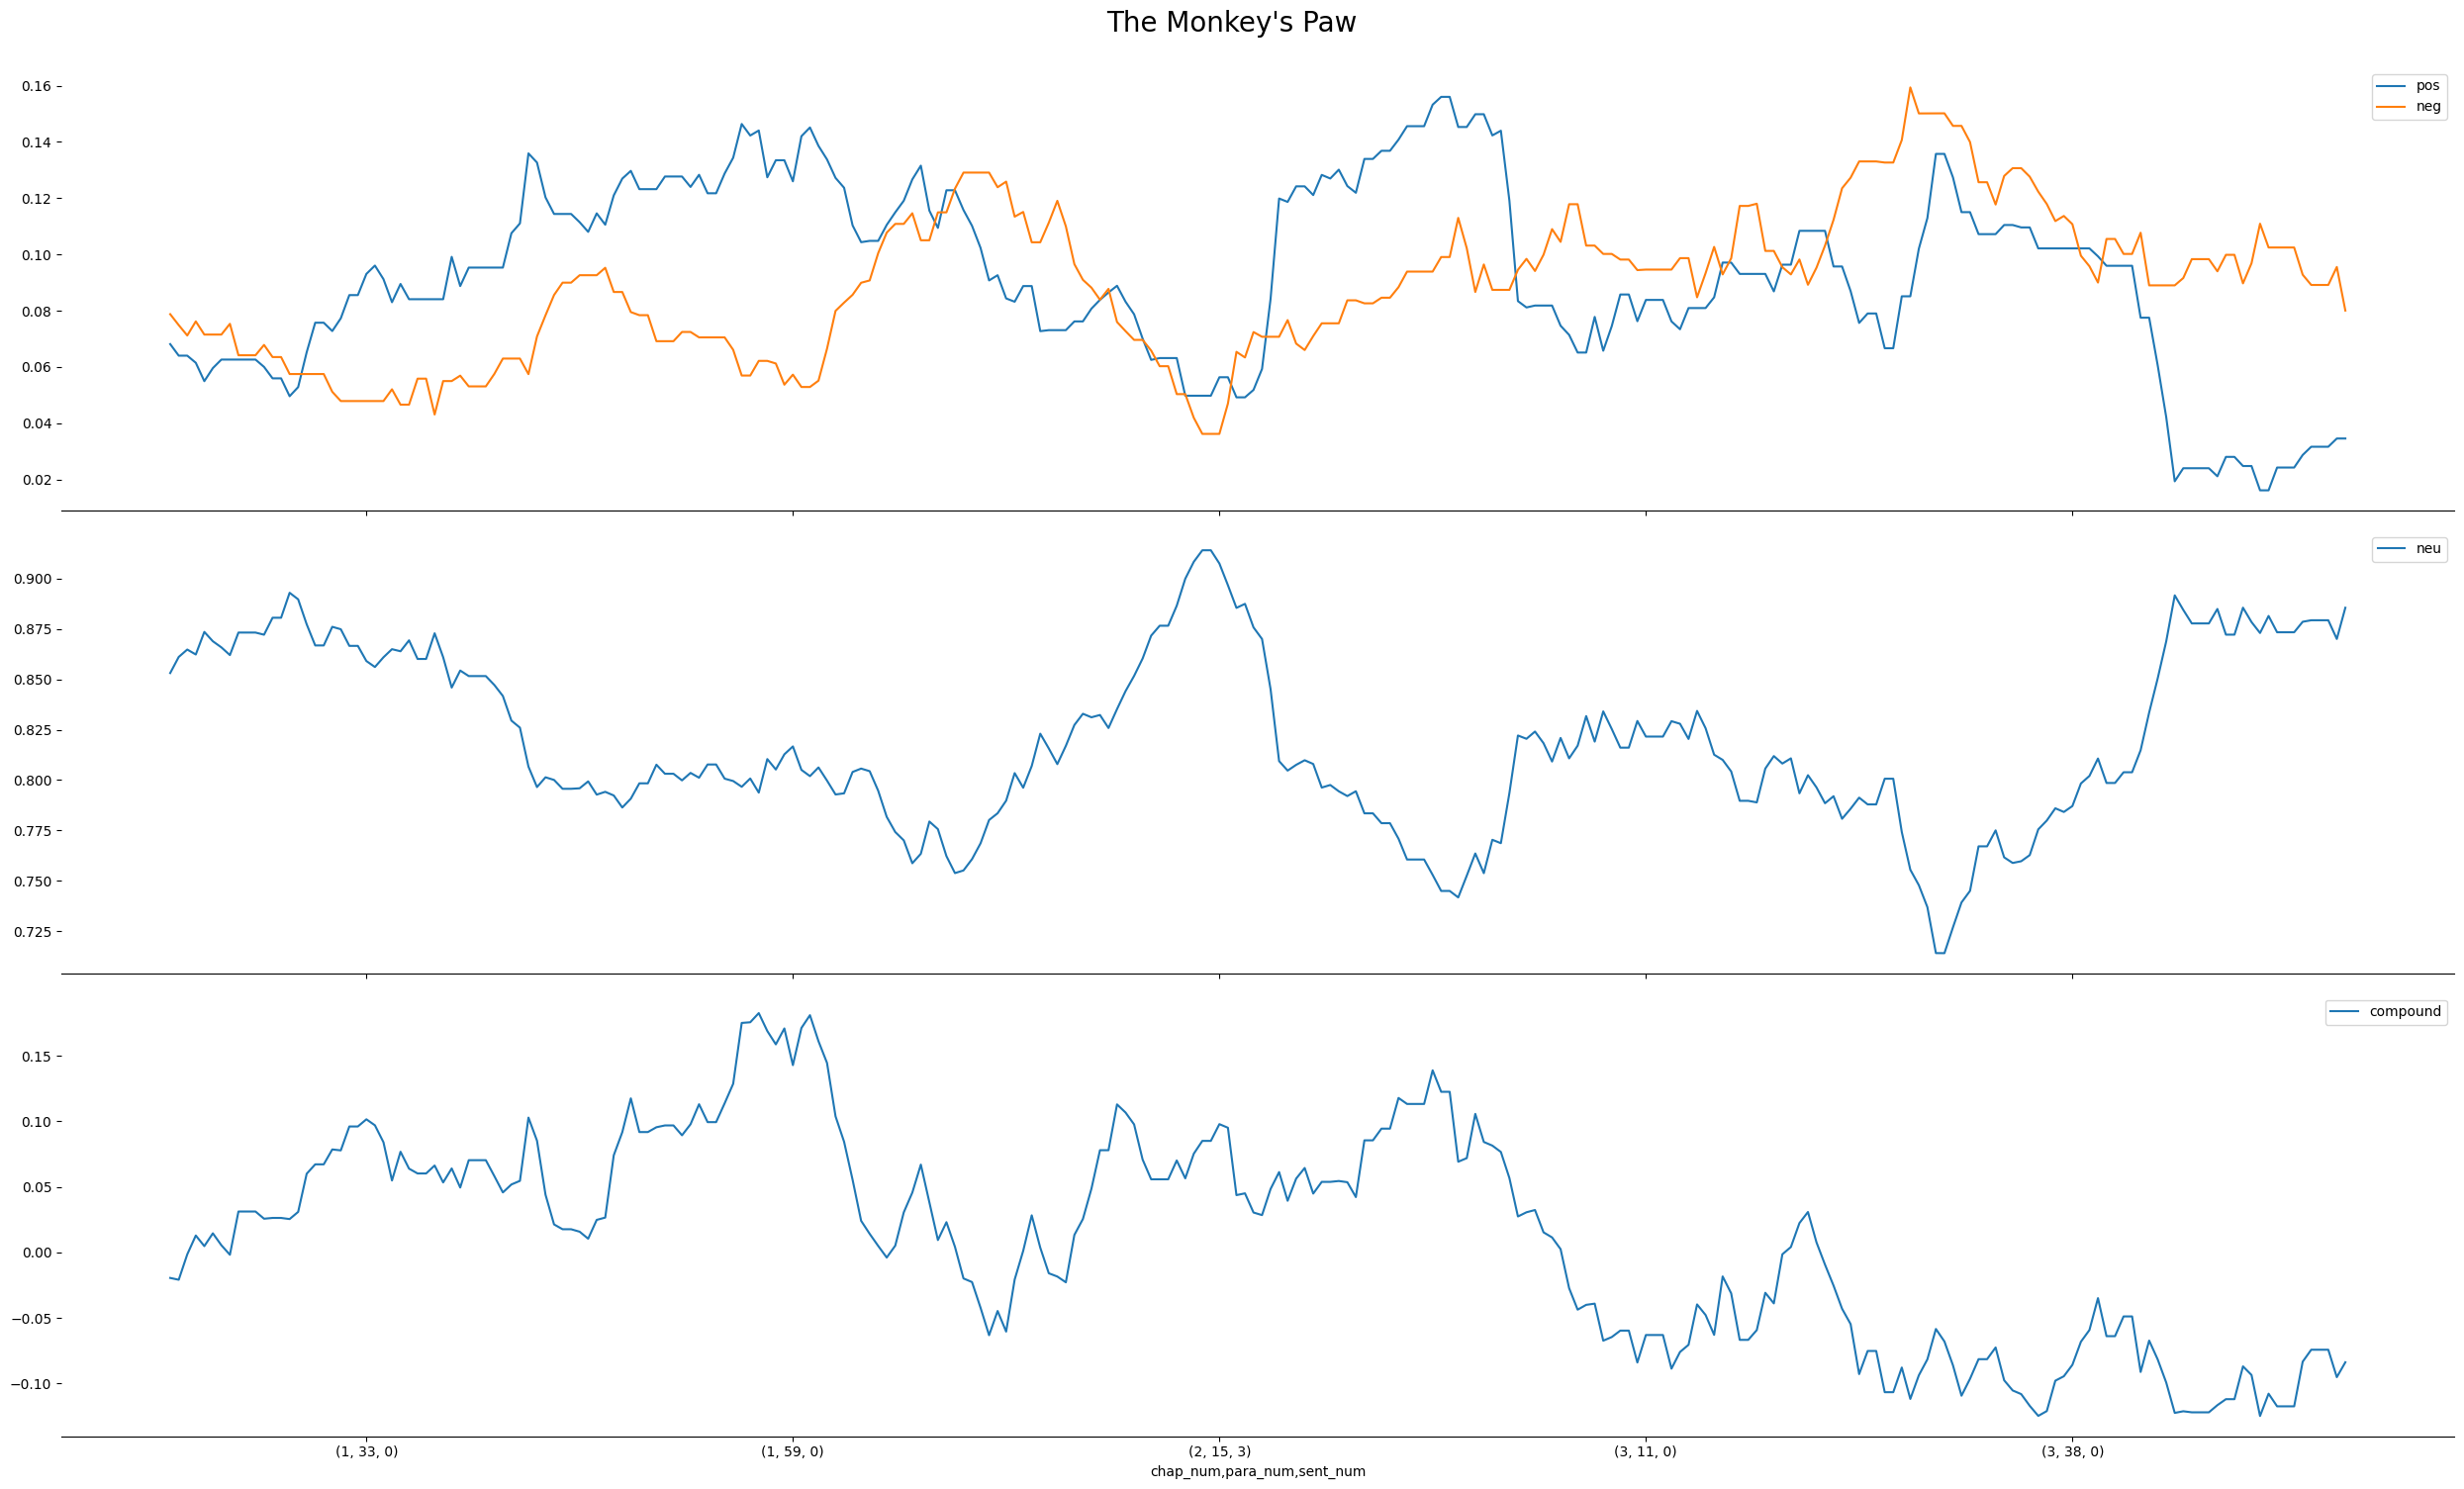

In [87]:
plot_book_sa(12122, 10)

In [89]:
def plot_book_sa(book_id, wf = 5):
    # wf: window size factor
    df = SENT_VADER.loc[book_id]
    w = int(df.shape[0] / wf)
    fig, axes = plt.subplots(3, 1, figsize=(25,15), sharex=True, sharey=False)
    plt.suptitle("The Haunting of Hill House", y=1, fontsize=20)
    df[['pos','neg']].rolling(w).mean().plot(ax=axes[0])
    df[['neu']].rolling(w).mean().plot(ax=axes[1])
    df[['compound']].rolling(w).mean().plot(ax=axes[2])
    plt.tight_layout()
    sns.despine(left=True)
    plt.show()

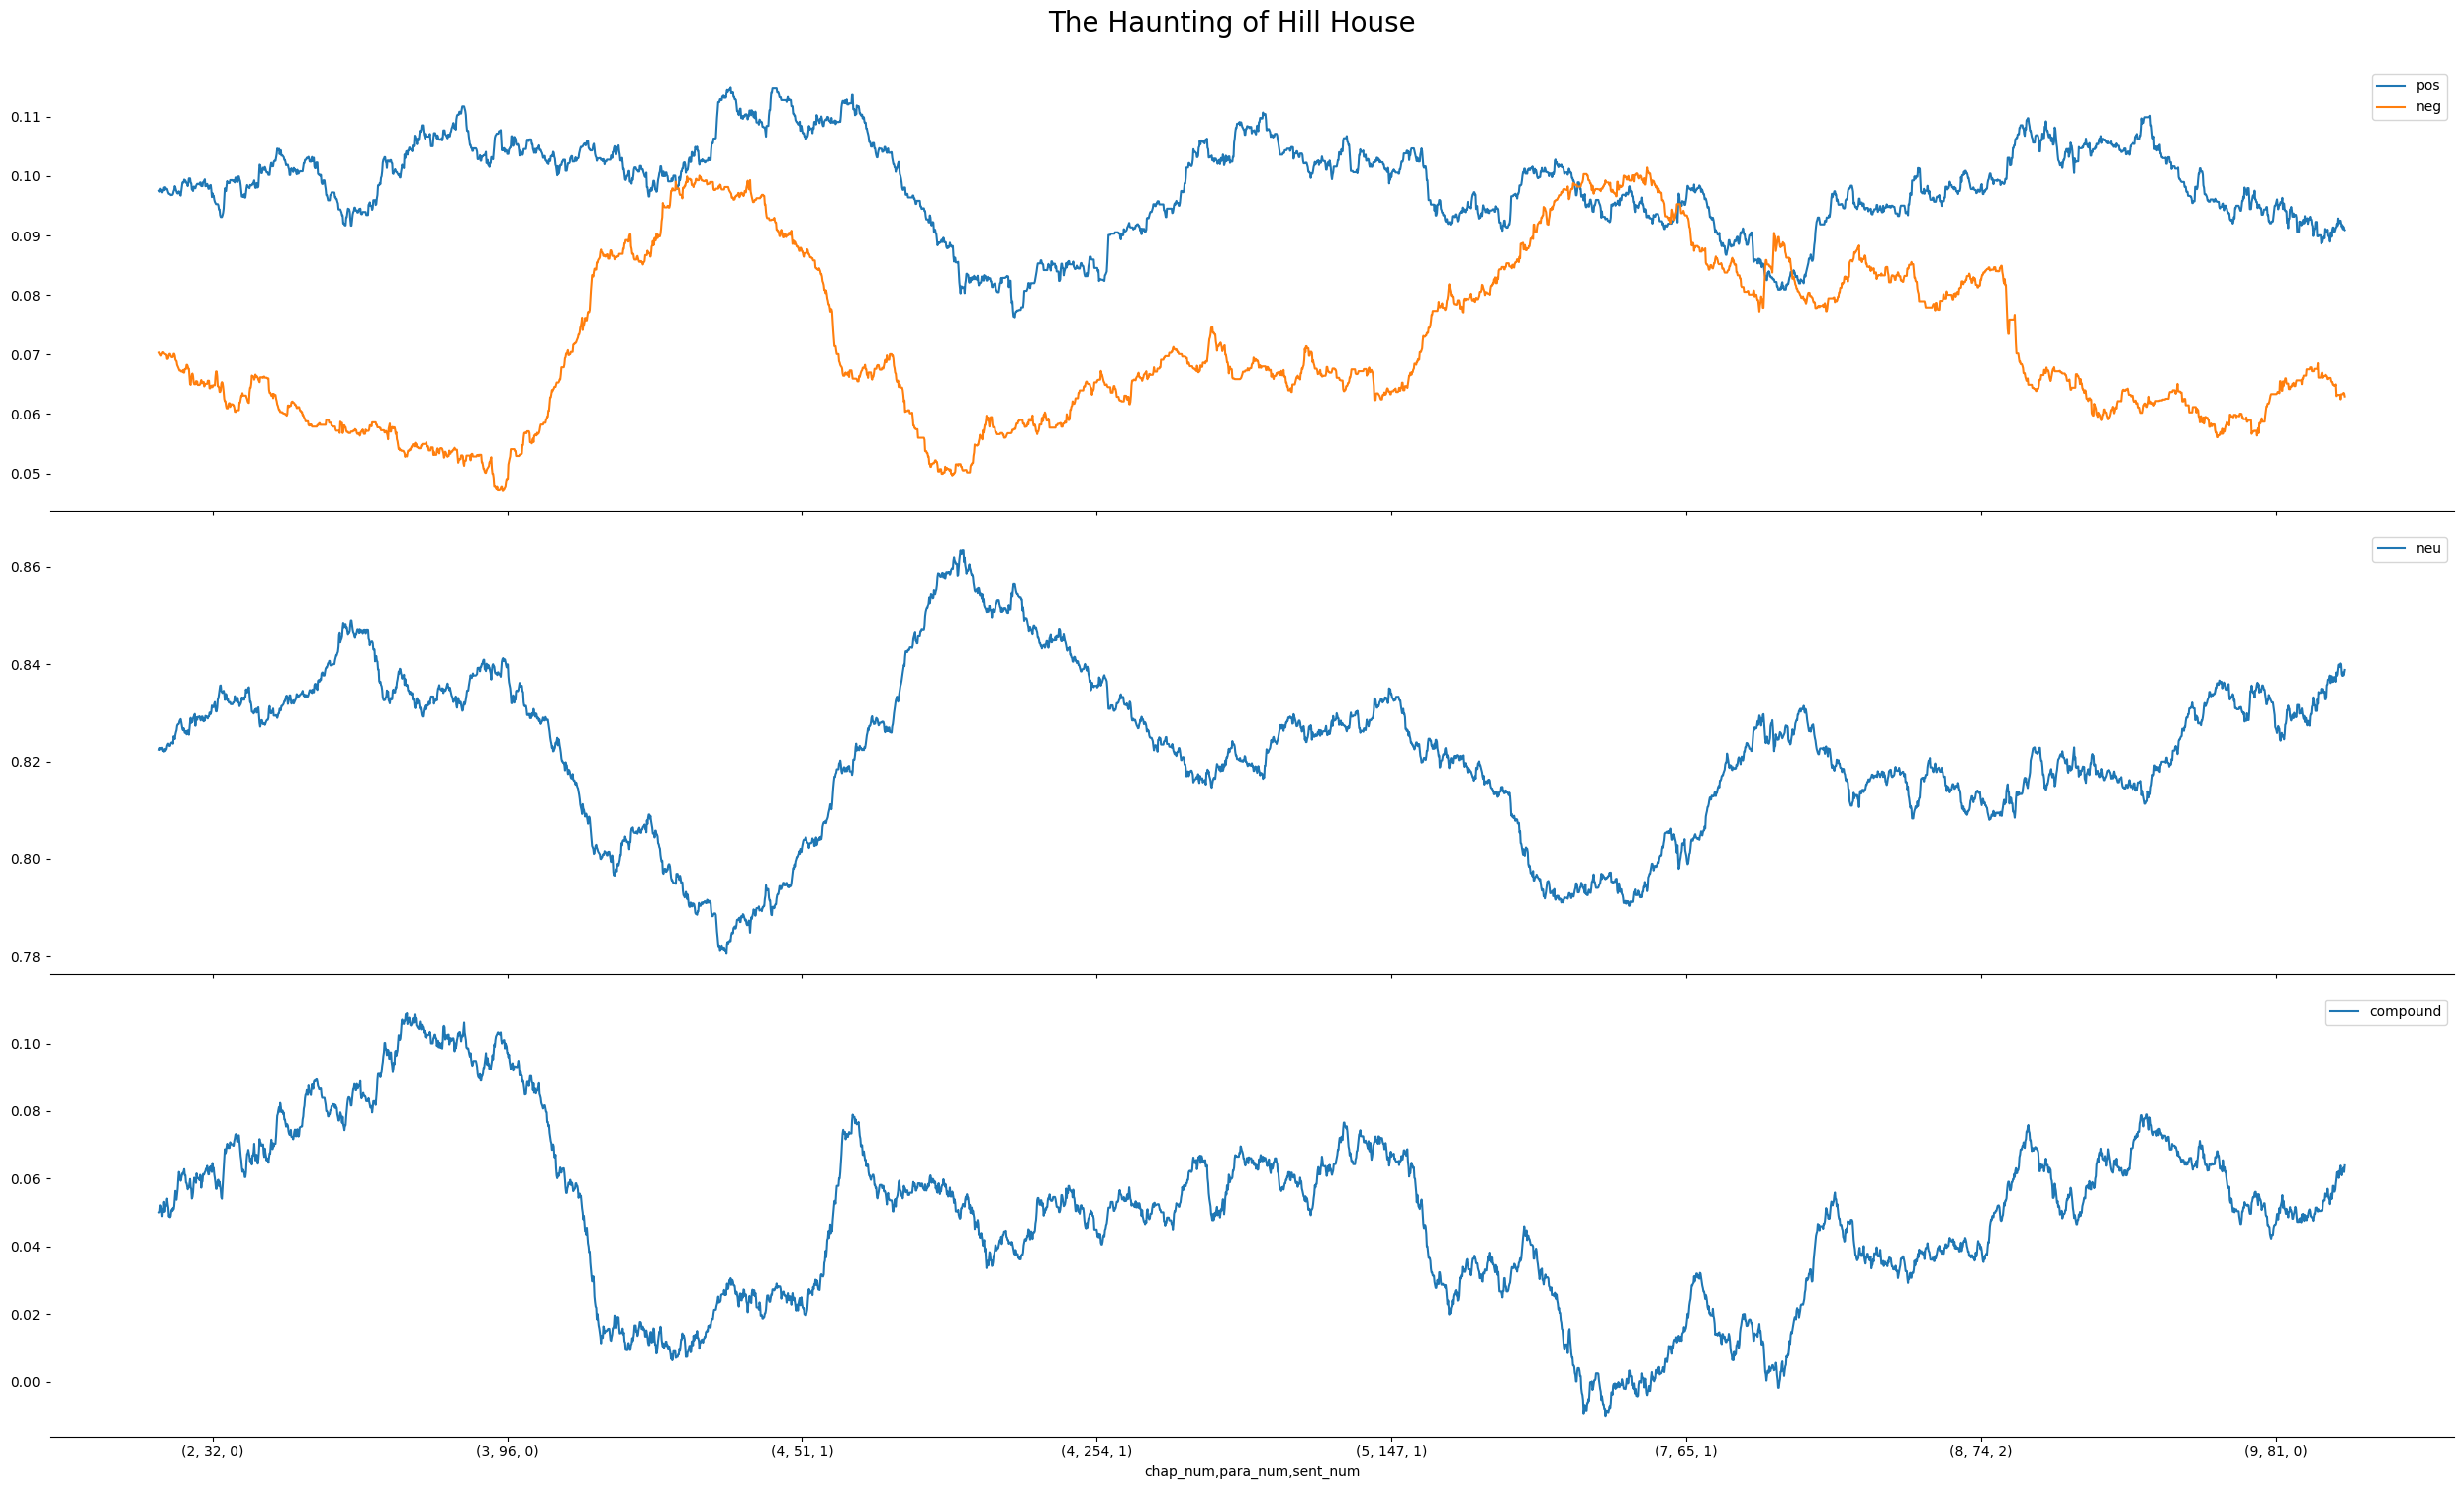

In [90]:
plot_book_sa(20180856, 10)